# AgriBot v2 — BERTScore Evaluation
**Fine-tuned FLAN-T5-base + RAG  vs  Out-of-the-box FLAN-T5-base**

Standalone evaluation notebook — assumes the fine-tuned model, FAISS index, and docs are already saved to Google Drive from the main training notebook.

In [1]:
pip install -q transformers datasets sentencepiece accelerate 

In [2]:
pip install -q sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 49.1 MB/s eta 0:00:0000:0100:01


In [3]:
pip install -q bert_score 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.9 MB/s eta 0:00:00


In [4]:
pip install google 

In [ ]:
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
warnings.filterwarnings('ignore')

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from bert_score import score as bert_score_fn
import faiss



In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
# ── Paths — update if yours differ ──────────────────────────────────────────
DATASET_DIR = '/content/drive/MyDrive/1_UM/1_NLP Project/dataset'
FT_MODEL_DIR = '/content/drive/MyDrive/1_UM/1_NLP Project/flan-t5-agribot-v2'
INDEX_PATH   = '/content/drive/MyDrive/1_UM/1_NLP Project/agribot_faiss.index'
DOCS_PATH    = '/content/drive/MyDrive/1_UM/1_NLP Project/agribot_docs.pkl'

BASE_MODEL   = 'google/flan-t5-base'
EMBED_MODEL  = 'sentence-transformers/all-MiniLM-L6-v2'

MAX_INPUT_LEN  = 256
MAX_TARGET_LEN = 128
MAX_RAG_INPUT  = 512
SEED           = 42  # must match training notebook split

print('Config ready.')

Config ready.


---
## Step 1 — Rebuild the test set
Re-run the same preprocessing + split with `SEED=42` to get the identical test questions and reference answers.

In [8]:
df_A = pd.read_csv(os.path.join(DATASET_DIR, 'agroqa_dataset.csv'))
df_B = pd.read_csv(os.path.join(DATASET_DIR, 'FAO_Manual_QA.csv'))
df_C = pd.read_csv(os.path.join(DATASET_DIR, 'agriculture-qa-english-only.csv'))

def clean_text(text):
    text = str(text).strip()
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_source(df, source_name, q_col, a_col, crop_col=None):
    out = pd.DataFrame()
    out['question'] = df[q_col].apply(clean_text)
    out['answer']   = df[a_col].apply(clean_text)
    if crop_col and crop_col in df.columns:
        out['crop'] = df[crop_col].astype(str).str.lower().str.strip().fillna('general').replace({'nan':'general','':'general'})
    else:
        out['crop'] = 'general'
    out['source'] = source_name
    return out

q_col_C = [c for c in df_C.columns if 'question' in c.lower()][0]
a_col_C = [c for c in df_C.columns if 'answer'   in c.lower()][0]

norm_A = normalize_source(df_A, 'agroqa',     'Question', 'Answer', 'Crop')
norm_B = normalize_source(df_B, 'fao_manual', 'Question', 'Answer', 'Crop')
norm_C = normalize_source(df_C, 'agri_qa',    q_col_C,    a_col_C)

df = pd.concat([norm_A, norm_B, norm_C], ignore_index=True)
df = df.dropna(subset=['question','answer'])
df = df[df['answer'].str.split().str.len() >= 3]
df = df.drop_duplicates(subset=['question','answer']).reset_index(drop=True)

GENERAL_CROPS = {'general','nan','','none'}
df['input_text'] = df.apply(
    lambda r: f"answer farming question about {r['crop']}: {r['question']}"
              if r['crop'] not in GENERAL_CROPS
              else f"answer farming question: {r['question']}",
    axis=1
)

_, df_temp = train_test_split(df, test_size=0.30, random_state=SEED)
_, df_test  = train_test_split(df_temp, test_size=0.50, random_state=SEED)
df_test = df_test.reset_index(drop=True)

print(f'Test set: {len(df_test)} rows')
df_test.head(3)

Test set: 717 rows


,question,answer,crop,source,input_text
0,how many times should I spray my maize,This depends on what you are sparing. But spra...,maize,agroqa,answer farming question about maize: how many ...
1,where can I store my dry cassava,A well ventilated store free from pests,cassava,agroqa,answer farming question about cassava: where c...
2,what mates my beans to rot inside the pod,Diseases especially fungal,beans,agroqa,answer farming question about beans: what mate...


---
## Step 2 — Load fine-tuned model + RAG components

In [11]:
tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_DIR)
ft_model  = AutoModelForSeq2SeqLM.from_pretrained(FT_MODEL_DIR).to(device)
ft_model.eval()
print('Fine-tuned model loaded.')

embed_model = SentenceTransformer(EMBED_MODEL, device=device)
faiss_index = faiss.read_index(INDEX_PATH)
with open(DOCS_PATH, 'rb') as f:
    kb_docs = pickle.load(f)
print(f'FAISS index: {faiss_index.ntotal:,} vectors')
print(f'Docs      : {len(kb_docs):,} records')

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Fine-tuned model loaded.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS index: 3,341 vectors
Docs      : 3,341 records


In [12]:
def retrieve(question, index, docs, embed_model, top_k=3, threshold=0.30):
    q_emb = embed_model.encode([question], normalize_embeddings=True,
                                convert_to_numpy=True).astype('float32')
    scores, idxs = index.search(q_emb, top_k)
    return [{**docs[i], 'score': float(s)}
            for s, i in zip(scores[0], idxs[0])
            if i >= 0 and float(s) >= threshold]

def build_rag_prompt(question, chunks):
    context = '\n'.join(f"[{i+1}] Q: {c['question']} A: {c['answer']}"
                        for i, c in enumerate(chunks))
    return (f"answer farming question using context:\n"
            f"Context:\n{context}\n\nQuestion: {question}")

def generate(prompt, model, max_new_tokens=128):
    inputs = tokenizer(prompt, return_tensors='pt',
                       max_length=MAX_RAG_INPUT, truncation=True).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                             num_beams=4, no_repeat_ngram_size=2, early_stopping=True)
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

print('RAG functions defined.')

RAG functions defined.


---
## Step 3 — Generate predictions from both models

In [13]:
from tqdm.auto import tqdm

ootb_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL).to(device)
ootb_model.eval()
print('Out-of-the-box model loaded.')

references, ft_preds, ootb_preds = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Generating'):
    question   = row['question']
    input_text = row['input_text']
    references.append(row['answer'])

    # Fine-tuned + RAG
    chunks = retrieve(question, faiss_index, kb_docs, embed_model)
    if chunks:
        prompt = build_rag_prompt(question, chunks)
    else:
        prompt = input_text          # fallback: no RAG context
    ft_preds.append(generate(prompt, ft_model))

    # Out-of-the-box (same prompt format, no RAG)
    ootb_preds.append(generate(input_text, ootb_model))

print(f'Done. {len(references)} predictions generated.')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Out-of-the-box model loaded.


Generating:   0%|          | 0/717 [00:00<?, ?it/s]

Done. 717 predictions generated.


---
## Step 4 — BERTScore Comparison

In [14]:
print('Computing BERTScore for fine-tuned + RAG …')
P_ft, R_ft, F1_ft = bert_score_fn(ft_preds, references, lang='en', verbose=True)

print('\nComputing BERTScore for out-of-the-box …')
P_ootb, R_ootb, F1_ootb = bert_score_fn(ootb_preds, references, lang='en', verbose=True)

print('\n' + '=' * 50)
print('BERTSCORE RESULTS')
print('=' * 50)
print(f"{'Model':<35} {'P':>7} {'R':>7} {'F1':>7}")
print('-' * 50)
print(f"{'Out-of-the-box FLAN-T5-base':<35} {P_ootb.mean():.4f} {R_ootb.mean():.4f} {F1_ootb.mean():.4f}")
print(f"{'AgriBot v2 (fine-tuned + RAG)':<35} {P_ft.mean():.4f}  {R_ft.mean():.4f}  {F1_ft.mean():.4f}")
print('-' * 50)
print(f"{'Delta':<35} {P_ft.mean()-P_ootb.mean():+.4f} {R_ft.mean()-R_ootb.mean():+.4f} {F1_ft.mean()-F1_ootb.mean():+.4f}")

Computing BERTScore for fine-tuned + RAG …


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/19 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/12 [00:00<?, ?it/s]

done in 7.74 seconds, 92.59 sentences/sec

BERTSCORE RESULTS
Model                                     P       R      F1
--------------------------------------------------
Out-of-the-box FLAN-T5-base         0.8530 0.8289 0.8405
AgriBot v2 (fine-tuned + RAG)       0.8274  0.8360  0.8313
--------------------------------------------------
Delta                               -0.0256 +0.0071 -0.0092


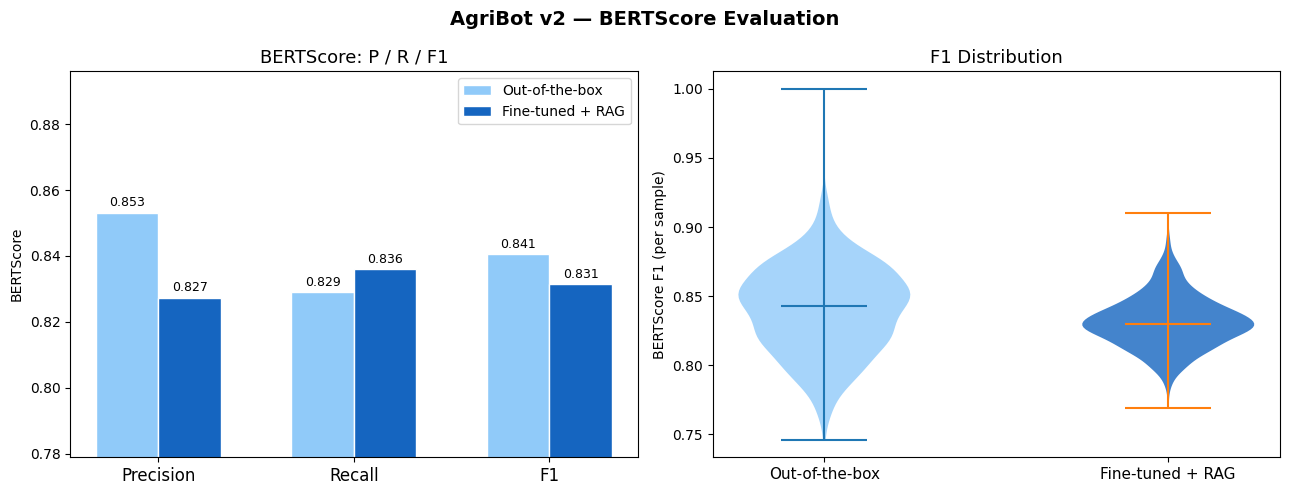

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: P / R / F1 grouped bar ────────────────────────────────────────────
metrics      = ['Precision', 'Recall', 'F1']
ootb_scores  = [P_ootb.mean().item(), R_ootb.mean().item(), F1_ootb.mean().item()]
ft_scores    = [P_ft.mean().item(),   R_ft.mean().item(),   F1_ft.mean().item()]

x, w = range(3), 0.32
bars_ootb = axes[0].bar([i - w/2 for i in x], ootb_scores, width=w,
                        label='Out-of-the-box', color='#90CAF9', edgecolor='white')
bars_ft   = axes[0].bar([i + w/2 for i in x], ft_scores,   width=w,
                        label='Fine-tuned + RAG', color='#1565C0', edgecolor='white')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(metrics, fontsize=12)
axes[0].set_ylabel('BERTScore'); axes[0].set_title('BERTScore: P / R / F1', fontsize=13)
axes[0].set_ylim(min(ootb_scores) - 0.05, max(ft_scores) + 0.06)
axes[0].legend(fontsize=10)
for bar in list(bars_ootb) + list(bars_ft):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# ── Right: F1 score distribution (violin) ───────────────────────────────────
parts_ootb = axes[1].violinplot(F1_ootb.numpy(), positions=[1], showmedians=True)
parts_ft   = axes[1].violinplot(F1_ft.numpy(),   positions=[2], showmedians=True)
for pc in parts_ootb['bodies']:  pc.set_facecolor('#90CAF9'); pc.set_alpha(0.8)
for pc in parts_ft['bodies']:    pc.set_facecolor('#1565C0'); pc.set_alpha(0.8)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Out-of-the-box', 'Fine-tuned + RAG'], fontsize=11)
axes[1].set_ylabel('BERTScore F1 (per sample)'); axes[1].set_title('F1 Distribution', fontsize=13)

plt.suptitle('AgriBot v2 — BERTScore Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bertscore_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Qualitative: highest & lowest F1 gain samples ───────────────────────────
delta_f1 = (F1_ft - F1_ootb).numpy()
df_results = pd.DataFrame({
    'question'  : df_test['question'].tolist(),
    'reference' : references,
    'ootb_pred' : ootb_preds,
    'ft_rag_pred': ft_preds,
    'f1_ootb'   : F1_ootb.numpy(),
    'f1_ft_rag' : F1_ft.numpy(),
    'delta_f1'  : delta_f1,
})

print('TOP 3 — Biggest improvement (fine-tuned + RAG wins)')
print('=' * 70)
for _, r in df_results.nlargest(3, 'delta_f1').iterrows():
    print(f"Q   : {r['question']}")
    print(f"REF : {r['reference']}")
    print(f"OOTB: {r['ootb_pred']}   [F1={r['f1_ootb']:.3f}]")
    print(f"FT  : {r['ft_rag_pred']}   [F1={r['f1_ft_rag']:.3f}]")
    print(f"Δ   : {r['delta_f1']:+.3f}")
    print('-' * 70)

print('\nBOTTOM 3 — Biggest regression (out-of-the-box wins)')
print('=' * 70)
for _, r in df_results.nsmallest(3, 'delta_f1').iterrows():
    print(f"Q   : {r['question']}")
    print(f"REF : {r['reference']}")
    print(f"OOTB: {r['ootb_pred']}   [F1={r['f1_ootb']:.3f}]")
    print(f"FT  : {r['ft_rag_pred']}   [F1={r['f1_ft_rag']:.3f}]")
    print(f"Δ   : {r['delta_f1']:+.3f}")
    print('-' * 70)

df_results.to_csv('bertscore_results.csv', index=False)
print('\nFull results saved → bertscore_results.csv')

TOP 3 — Biggest improvement (fine-tuned + RAG wins)
Q   : what makes my maize leaves to be dry at this time
REF : Drought or disease
OOTB: safflower   [F1=0.816]
FT  : It is a disease.   [F1=0.910]
Δ   : +0.094
----------------------------------------------------------------------
Q   : what makes cassava to get dry
REF : Poor soils, infection of diseases an invasion of ants
OOTB: sulphur   [F1=0.792]
FT  : It is a disease, and the disease is in the plant.   [F1=0.880]
Δ   : +0.088
----------------------------------------------------------------------
Q   : How do you know when citrus fruits are ready for harvest?
REF : Citrus fruits are typically ready for harvest when they reach full color, are firm to the touch, and are easily detached from the tree with a slight twist.
OOTB: ripening   [F1=0.782]
FT  : It is a good time to harvest citrus fruits, and if they are ripe, they can be drained in sassava, osea, or tees.   [F1=0.864]
Δ   : +0.082
-------------------------------------------